In [1]:
from google import colab
colab.drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
!ls /content/drive/MyDrive/ml4accelerators/datasets/


neural_pycolleff_dataset_2026-04-23T14:45:35.npz
neural_pycolleff_dataset_2026-04-27T17:11:49.npz
neural_xsuite_dataset_2026-04-28T09:40:32.npz
neural_xsuite_dataset_2026-04-28T09:44:22.npz
neural_xsuite_dataset_2026-04-28T09:46:07.npz
neural_xsuite_dataset_2026-04-29T12:26:38.npz
Test_pycolleff_dataset.npz
xsuite_dataset.npz
xsuite_dataset_validation.npz
xsuite_neural_dataset_metadata.json
xsuite_neural_dataset.npz
xsuite_neural_pycolleff_dataset.npz
xsuite_operator_dataset.npz


In [11]:
# Notebook cell: imports
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [43]:
# Notebook cell: config (edit these)
DATASET_PATH = "/content/drive/MyDrive/ml4accelerators/datasets/neural_xsuite_dataset_2026-04-29T12:26:38.npz"
raw = np.load(DATASET_PATH, allow_pickle=True)

X = raw["X_cloud"]          # [Ns, Np, 6]
Y = raw["Y_cloud"]
MU = raw["MU"]
train_idx = raw["train"]
val_idx = raw["val"]

print("X:", X.shape, X.dtype, "MU:", MU.shape)

X: (512, 512, 6) float32 MU: (512, 3)


In [38]:
def get_n_points(npz_path: str):
    raw = np.load(npz_path, allow_pickle=True)
    return raw["X_cloud"].shape[1]


In [39]:
def soft_kde2d(u, v, u_grid, v_grid, su, sv):
    """
    u,v: [B,N]
    u_grid: [Hu], v_grid:[Wv]
    returns rho: [B, Hu, Wv] (not yet normalized by du*dv)
    """
    # [B,N,1,1] - [1,1,Hu,1] => [B,N,Hu,1]
    du = (u[:, :, None, None] - u_grid[None, None, :, None]) / su
    dv = (v[:, :, None, None] - v_grid[None, None, None, :]) / sv
    w = torch.exp(-0.5 * (du**2 + dv**2))  # [B,N,Hu,Wv]
    rho = w.mean(dim=1)                   # average over particles -> [B,Hu,Wv]
    return rho

def normalize_density(rho, u_grid, v_grid):
    du = (u_grid[-1] - u_grid[0]) / max(1, u_grid.numel() - 1)
    dv = (v_grid[-1] - v_grid[0]) / max(1, v_grid.numel() - 1)
    mass = rho.sum(dim=(-2, -1), keepdim=True) * du * dv
    return rho / (mass + 1e-12)

In [40]:
# Notebook cell: Chamfer loss
def chamfer_l2(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    # a,b: [B,N,6]
    dist = torch.cdist(a, b, p=2) ** 2
    min_a = dist.min(dim=2).values
    min_b = dist.min(dim=1).values
    return (min_a.mean() + min_b.mean())

In [41]:
def percentile_range(a, lo=0.5, hi=99.5):
    return np.percentile(a, lo), np.percentile(a, hi)

# compute ranges from a subset of training points for speed
sub = X[train_idx[:50]]  # [50,Np,6]
xr = percentile_range(sub[:,:,0].ravel())
pxr = percentile_range(sub[:,:,3].ravel())
yr = percentile_range(sub[:,:,1].ravel())
pyr = percentile_range(sub[:,:,4].ravel())
zr = percentile_range(sub[:,:,2].ravel())
dr = percentile_range(sub[:,:,5].ravel())

print("x range", xr, "px range", pxr)
print("y range", yr, "py range", pyr)
print("zeta range", zr, "delta range", dr)

# grids
Hx = 64; Wpx = 64
Hy = 64; Wpy = 64
Hz = 64; Wd = 64

x_grid  = torch.linspace(xr[0],  xr[1],  Hx)
px_grid = torch.linspace(pxr[0], pxr[1], Wpx)
y_grid  = torch.linspace(yr[0],  yr[1],  Hy)
py_grid = torch.linspace(pyr[0], pyr[1], Wpy)
z_grid  = torch.linspace(zr[0],  zr[1],  Hz)
d_grid  = torch.linspace(dr[0],  dr[1],  Wd)

# kernel widths (rule of thumb: a few grid steps)
sx  = float((x_grid[1]-x_grid[0]) * 2.0)
spx = float((px_grid[1]-px_grid[0]) * 2.0)
sy  = float((y_grid[1]-y_grid[0]) * 2.0)
spy = float((py_grid[1]-py_grid[0]) * 2.0)
sz  = float((z_grid[1]-z_grid[0]) * 2.0)
sd  = float((d_grid[1]-d_grid[0]) * 2.0)

print("sigmas:", sx, spx, sy, spy, sz, sd)

x range (np.float32(-0.004696944), np.float32(0.004565476)) px range (np.float32(-0.0046702293), np.float32(0.004638049))
y range (np.float32(-0.004631985), np.float32(0.0045846854)) py range (np.float32(-0.0045991363), np.float32(0.004693025))
zeta range (np.float32(-0.003718098), np.float32(0.0038072662)) delta range (np.float32(-0.000365078), np.float32(0.00037706172))
sigmas: 0.0002940446138381958 0.0002955012023448944 0.00029259268194437027 0.0002949889749288559 0.000238900538533926 2.356001641601324e-05


In [24]:
def cloud_to_fields(cloud_batch):
    """
    cloud_batch: torch [B,Np,6]
    returns fields: [B, 3, 64, 64] corresponding to (x,px), (y,py), (zeta,delta)
    """
    x  = cloud_batch[:,:,0]
    y  = cloud_batch[:,:,1]
    zt = cloud_batch[:,:,2]
    px = cloud_batch[:,:,3]
    py = cloud_batch[:,:,4]
    de = cloud_batch[:,:,5]

    rho_x = normalize_density(soft_kde2d(x,  px, x_grid,  px_grid, sx,  spx), x_grid,  px_grid)
    rho_y = normalize_density(soft_kde2d(y,  py, y_grid,  py_grid, sy,  spy), y_grid,  py_grid)
    rho_z = normalize_density(soft_kde2d(zt, de, z_grid,  d_grid,  sz,  sd),  z_grid,  d_grid)
    return torch.stack([rho_x, rho_y, rho_z], dim=1)

# test on one batch
xb = torch.from_numpy(X[train_idx[:2]]).float()
fields = cloud_to_fields(xb)
print(fields.shape, fields.min().item(), fields.max().item())

torch.Size([2, 3, 64, 64]) 3.463415657839429e-25 1502399.375


In [27]:
import torch.nn as nn
import torch.nn.functional as F

class FieldAE(nn.Module):
    def __init__(self, in_ch=3, latent_dim=128):
        super().__init__()
        # encoder: [B,3,64,64] -> [B,latent]
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.GELU(),   # 32x32
            nn.Conv2d(32, 64, 3, padding=1), nn.GELU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.GELU(),   # 16x16
            nn.Conv2d(64, 128, 3, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.enc_fc = nn.Linear(128, latent_dim)

        # decoder: [B,latent] -> [B,3,64,64]
        self.dec_fc = nn.Linear(latent_dim, 128 * 16 * 16)
        self.dec = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="nearest"),            # 32x32
            nn.Conv2d(128, 64, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="nearest"),            # 64x64
            nn.Conv2d(64, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, in_ch, 1),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.enc_fc(h)

    def decode(self, z):
        h = self.dec_fc(z).view(z.size(0), 128, 16, 16)
        x = self.dec(h)
        # enforce positivity and unit-mass per channel with softplus + normalization
        x = F.softplus(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

def normalize_channels(x):
    # x: [B,3,H,W] nonnegative
    # normalize each channel to mass=1 under du*dv (approx using sum only; good enough for training)
    s = x.sum(dim=(-2,-1), keepdim=True)
    return x / (s + 1e-12)


def field_loss(x_hat, x):
    x_hat = normalize_channels(x_hat)
    x = normalize_channels(x)
    return torch.mean((x_hat - x)**2)

In [44]:
from torch.utils.data import Dataset, DataLoader

class FieldDataset(Dataset):
    def __init__(self, clouds_np, idx):
        self.clouds = clouds_np
        self.idx = idx

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        cloud = torch.from_numpy(self.clouds[self.idx[i]]).float()
        return cloud_to_fields(cloud.unsqueeze(0))[0]  # [3,64,64]

train_ds = FieldDataset(X, train_idx[:400])  # start small
val_ds   = FieldDataset(X, val_idx[:100])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device : ", device)
model = FieldAE(in_ch=3, latent_dim=128).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

@torch.no_grad()
def eval_val():
    model.eval()
    s=0.0; n=0
    for f in val_loader:
        f = f.to(device)
        f_hat, _ = model(f)
        loss = field_loss(f_hat, f)
        s += loss.item()*f.size(0); n += f.size(0)
    return s/max(1,n)

for epoch in range(1, 21):
    model.train()
    s=0.0; n=0
    for f in train_loader:
        f = f.to(device)
        f_hat, z = model(f)
        loss = field_loss(f_hat, f)
        opt.zero_grad()
        loss.backward()
        opt.step()
        s += loss.item()*f.size(0); n += f.size(0)
    if epoch==1 or epoch%5==0:
        print("epoch", epoch, "train", s/n, "val", eval_val())

device :  cuda
epoch 1 train 8.545250857139308e-08 val 5.7570351518667365e-08
epoch 5 train 4.958321319747938e-08 val 4.656184924333413e-08
epoch 10 train 4.9037878611102315e-08 val 4.5812321396138655e-08
epoch 15 train 1.6429972280462836e-08 val 1.583894747820487e-08
epoch 20 train 1.141734133014438e-08 val 1.139532001656999e-08


Ztr (240, 128) mean/std 1.2531999 140.42615


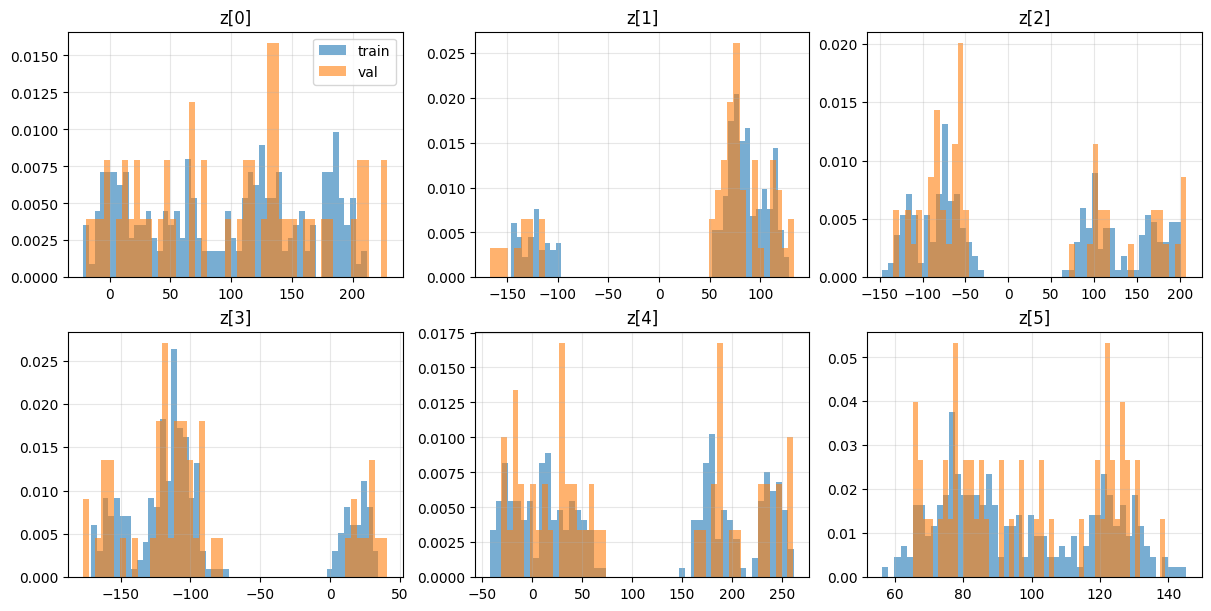

In [48]:
@torch.no_grad()
def collect_latents(model,loader, max_batches=30):
    model.eval()
    Z=[]
    for bi, f in enumerate(loader):
        if bi>=max_batches: break
        f = f.to(device)
        _, z = model(f)
        Z.append(z.cpu().numpy())
    return np.vstack(Z)

Ztr = collect_latents(model,train_loader)
Zva = collect_latents(model, val_loader)
print("Ztr", Ztr.shape, "mean/std", Ztr.mean(), Ztr.std())

# histogram a few dims
dims = [0,1,2,3,4,5]
fig, ax = plt.subplots(2,3, figsize=(12,6), constrained_layout=True)
ax=ax.ravel()
for a,d in zip(ax,dims):
    a.hist(Ztr[:,d], bins=50, alpha=0.6, density=True, label="train")
    a.hist(Zva[:,d], bins=50, alpha=0.6, density=True, label="val")
    a.set_title(f"z[{d}]")
    a.grid(alpha=0.3)
ax[0].legend()
plt.show()

In [46]:
#save AutoEncoder
out_path = "/content/drive/MyDrive/ml4accelerators/models/autoencoder.pt"
torch.save(
        {
            "state_dict": model.state_dict(),
        },
        out_path,
)


In [52]:
#load model
model_load = torch.load("/content/drive/MyDrive/ml4accelerators/models/autoencoder.pt")
model.load_state_dict(model_load["state_dict"])
model.eval()


FieldAE(
  (enc): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): GELU(approximate='none')
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): GELU(approximate='none')
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): GELU(approximate='none')
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): GELU(approximate='none')
    (10): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (enc_fc): Linear(in_features=128, out_features=128, bias=True)
  (dec_fc): Linear(in_features=128, out_features=32768, bias=True)
  (dec): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): Upsample(scale_factor=2.0, mode='nearest')
    (3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1

Ztr (240, 128) mean/std 1.1950195 140.57314


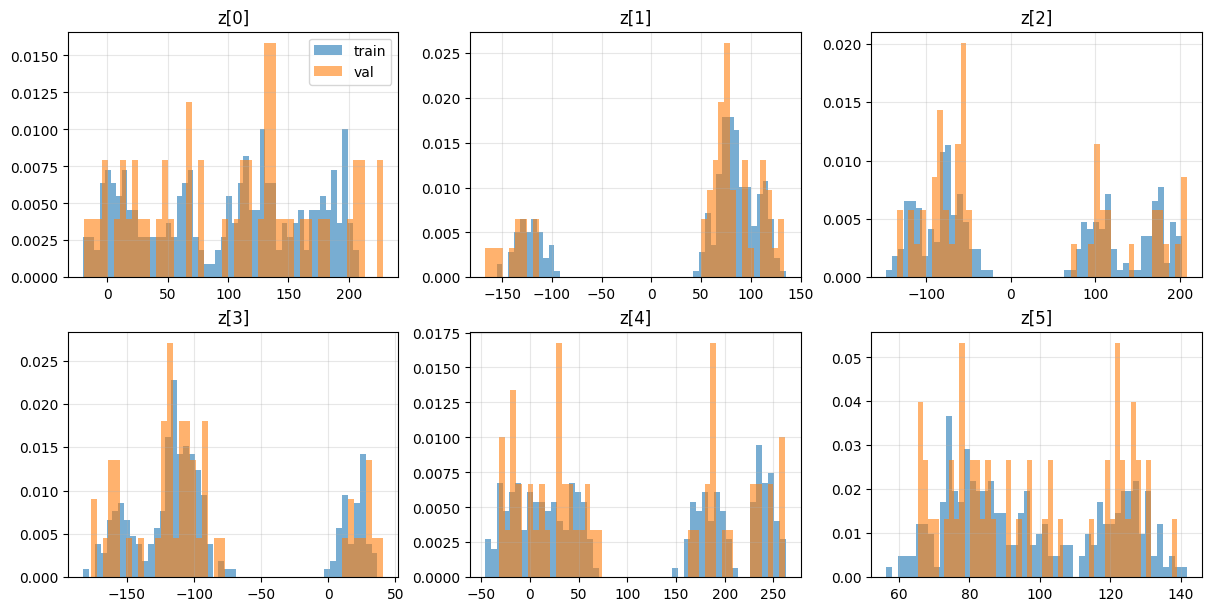

In [53]:
Ztr = collect_latents(model,train_loader)
Zva = collect_latents(model, val_loader)
print("Ztr", Ztr.shape, "mean/std", Ztr.mean(), Ztr.std())

# histogram a few dims
dims = [0,1,2,3,4,5]
fig, ax = plt.subplots(2,3, figsize=(12,6), constrained_layout=True)
ax=ax.ravel()
for a,d in zip(ax,dims):
    a.hist(Ztr[:,d], bins=50, alpha=0.6, density=True, label="train")
    a.hist(Zva[:,d], bins=50, alpha=0.6, density=True, label="val")
    a.set_title(f"z[{d}]")
    a.grid(alpha=0.3)
ax[0].legend()
plt.show()

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_planes(true_fields, recon_fields, grids, title=""):
    """
    true_fields, recon_fields: [3,H,W] torch or np
    grids: dict with keys for each plane: (u_grid, v_grid)
    """
    if isinstance(true_fields, torch.Tensor):
        true_fields = true_fields.detach().cpu().numpy()
    if isinstance(recon_fields, torch.Tensor):
        recon_fields = recon_fields.detach().cpu().numpy()

    planes = [
        ("x-px", 0, grids["xpx"][0], grids["xpx"][1]),
        ("y-py", 1, grids["ypy"][0], grids["ypy"][1]),
        ("zeta-delta", 2, grids["zd"][0], grids["zd"][1]),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True)
    if title:
        fig.suptitle(title, fontsize=14)

    for row, (name, ch, ug, vg) in enumerate(planes):
        # imshow expects [H,W] and uses extent=[xmin,xmax,ymin,ymax]
        extent = [vg[0], vg[-1], ug[0], ug[-1]]  # x-axis=v, y-axis=u (just a convention)

        im0 = axes[row, 0].imshow(true_fields[ch], origin="lower", aspect="auto", extent=extent, cmap="viridis")
        axes[row, 0].set_title(f"TRUE {name}")
        axes[row, 0].set_xlabel(name.split("-")[1])
        axes[row, 0].set_ylabel(name.split("-")[0])
        fig.colorbar(im0, ax=axes[row, 0], fraction=0.046)

        im1 = axes[row, 1].imshow(recon_fields[ch], origin="lower", aspect="auto", extent=extent, cmap="viridis")
        axes[row, 1].set_title(f"RECON {name}")
        axes[row, 1].set_xlabel(name.split("-")[1])
        axes[row, 1].set_ylabel(name.split("-")[0])
        fig.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    plt.show()

latent shape: torch.Size([1, 128])
latent mean/std: 12.7701997756958 144.77099609375


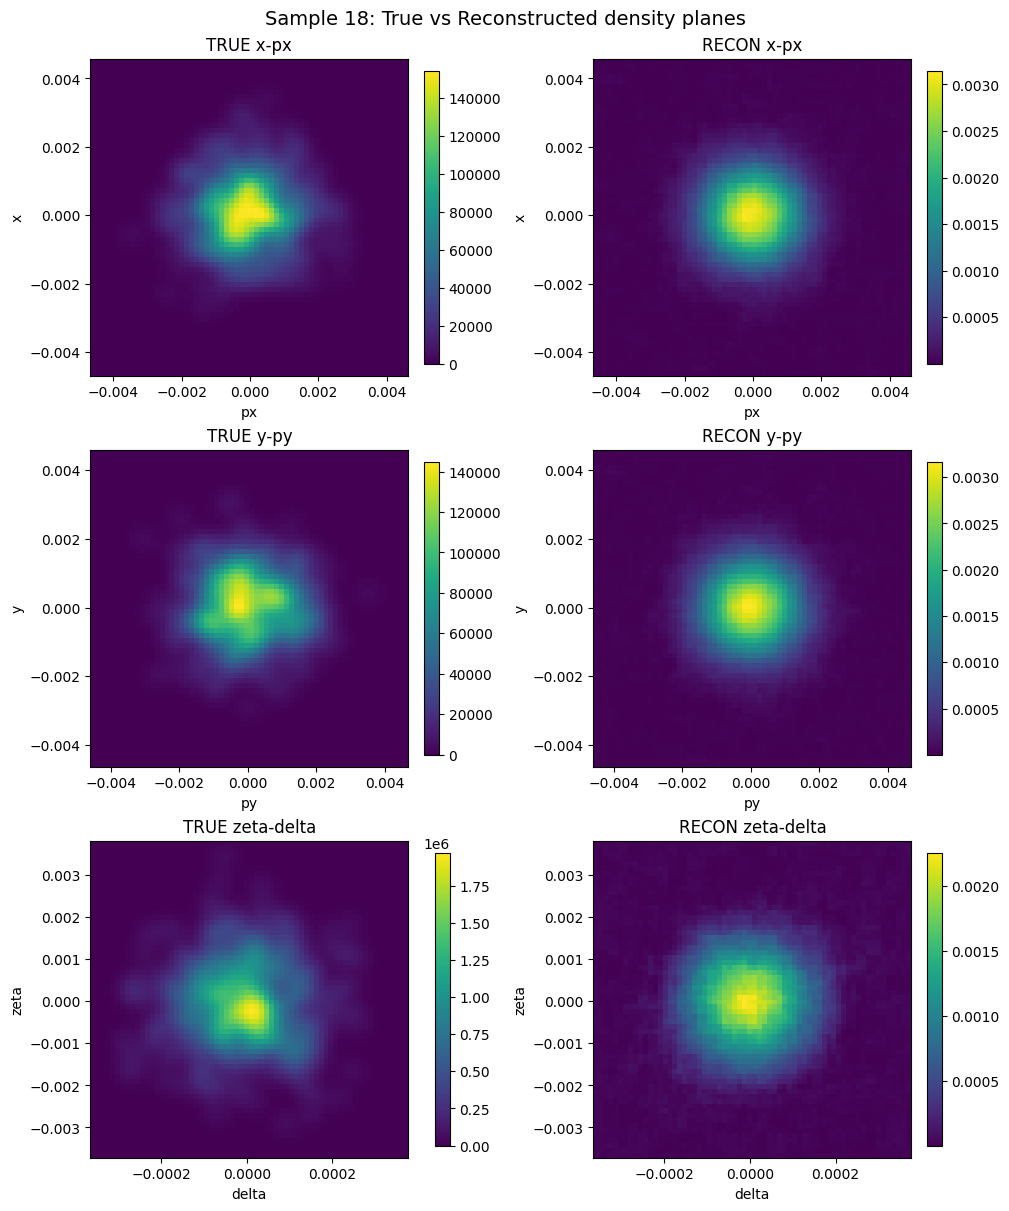

In [56]:
i = int(train_idx[0])  # or val_idx[0]

cloud = torch.from_numpy(X[i]).float().unsqueeze(0)  # [1,Np,6]
true_fields = cloud_to_fields(cloud)[0]              # [3,H,W]

model.eval()
device = next(model.parameters()).device
with torch.no_grad():
    f = true_fields.unsqueeze(0).to(device)          # [1,3,H,W]
    f_hat, z = model(f)                              # f_hat: [1,3,H,W], z: [1,latent]
    f_hat = normalize_channels(f_hat)[0].cpu()       # [3,H,W]

print("latent shape:", z.shape)
print("latent mean/std:", z.mean().item(), z.std().item())

grids = {
    "xpx": (x_grid.cpu().numpy(), px_grid.cpu().numpy()),
    "ypy": (y_grid.cpu().numpy(), py_grid.cpu().numpy()),
    "zd":  (z_grid.cpu().numpy(), d_grid.cpu().numpy()),
}

plot_planes(true_fields, f_hat, grids, title=f"Sample {i}: True vs Reconstructed density planes")

In [57]:
import torch
from torch.utils.data import Dataset

class OperatorFieldDataset(Dataset):
    def __init__(self, X, Y, MU, idx):
        self.X = X
        self.Y = Y
        self.MU = MU
        self.idx = idx

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, k):
        i = int(self.idx[k])
        x = torch.from_numpy(self.X[i]).float().unsqueeze(0)   # [1,Np,6]
        y = torch.from_numpy(self.Y[i]).float().unsqueeze(0)
        Fin = cloud_to_fields(x)[0]    # [3,64,64]
        Fout = cloud_to_fields(y)[0]   # [3,64,64]
        mu = torch.from_numpy(self.MU[i]).float()              # [3]
        return Fin, Fout, mu

In [59]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class FieldTokenAE(nn.Module):
    """
    Encode [B,3,64,64] -> tokens Z [B,T=64,C]
    Decode tokens back -> [B,3,64,64]
    """
    def __init__(self, in_ch=3, token_dim=64):
        super().__init__()
        # downsample 64->32->16->8
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.GELU(),      # 32x32
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.GELU(),      # 16x16
            nn.Conv2d(64, token_dim, 3, stride=2, padding=1), nn.GELU()# 8x8
        )
        # upsample 8->16->32->64
        self.dec = nn.Sequential(
            nn.Conv2d(token_dim, 64, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="nearest"),               # 16x16
            nn.Conv2d(64, 64, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="nearest"),               # 32x32
            nn.Conv2d(64, 32, 3, padding=1), nn.GELU(),
            nn.Upsample(scale_factor=2, mode="nearest"),               # 64x64
            nn.Conv2d(32, in_ch, 1),
        )

    def encode_tokens(self, f):
        h = self.enc(f)                    # [B,C,8,8]
        B,C,H,W = h.shape                  # H=W=8
        Z = h.permute(0,2,3,1).reshape(B, H*W, C)  # [B,64,C]
        return Z

    def decode_tokens(self, Z):
        B,T,C = Z.shape
        side = int(T**0.5)                 # 8
        h = Z.reshape(B, side, side, C).permute(0,3,1,2)  # [B,C,8,8]
        out = self.dec(h)                  # [B,3,64,64]
        out = F.softplus(out)
        out = out / (out.sum(dim=(-2,-1), keepdim=True) + 1e-12)  # per-channel mass normalize
        return out

    def forward(self, f):
        Z = self.encode_tokens(f)
        f_hat = self.decode_tokens(Z)
        return f_hat, Z

def field_loss(x_hat, x):
    x_hat = x_hat / (x_hat.sum(dim=(-2,-1), keepdim=True) + 1e-12)
    x     = x     / (x.sum(dim=(-2,-1), keepdim=True) + 1e-12)
    return torch.mean((x_hat - x)**2)

In [61]:


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes: int) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / max(1, in_channels * out_channels)
        self.weight_real = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes)
        )
        self.weight_imag = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes)
        )

    def compl_weight(self) -> torch.Tensor:
        return torch.complex(self.weight_real, self.weight_imag)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C, N]
        batch, _, n = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        n_modes = min(self.modes, x_ft.shape[-1])
        out_ft = torch.zeros(
            batch,
            self.out_channels,
            x_ft.shape[-1],
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, :n_modes] = torch.einsum(
            "bim,iom->bom",
            x_ft[:, :, :n_modes],
            self.compl_weight()[:, :, :n_modes],
        )
        x = torch.fft.irfft(out_ft, n=n, dim=-1)
        return x


class FNOBlock1d(nn.Module):
    def __init__(self, width: int, modes: int) -> None:
        super().__init__()
        self.spectral = SpectralConv1d(width, width, modes)
        self.local = nn.Conv1d(width, width, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.spectral(x) + self.local(x))


class FNO1d(nn.Module):
    def __init__(
        self,
        in_channels: int = 5,
        width: int = 64,
        modes: int = 16,
        depth: int = 4,
        hidden_proj: int = 128,
    ) -> None:
        super().__init__()
        self.lift = nn.Linear(in_channels, width)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(depth)])
        self.proj1 = nn.Conv1d(width, hidden_proj, kernel_size=1)
        self.proj2 = nn.Conv1d(hidden_proj, 1, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, N, C]
        x = self.lift(x)            # [B, N, W]
        x = x.permute(0, 2, 1)      # [B, W, N]
        for block in self.blocks:
            x = block(x)
        x = self.act(self.proj1(x))
        x = self.proj2(x)
        return x[:, 0, :]           # [B, N]


In [64]:
import torch
import torch.nn as nn

class LatentFNO1d(nn.Module):
    """
    Latent operator on token sequence.

    Inputs:
      z_in: [B, T, Ctok]
      mu:   [B, mu_dim]  (your 3 parameters)
    Output:
      z_out: [B, T, Ctok]
    """
    def __init__(self, token_dim=64, mu_dim=3, width=128, modes=16, depth=4, hidden_proj=128):
        super().__init__()
        self.token_dim = token_dim
        self.mu_dim = mu_dim

        in_channels = token_dim + mu_dim + 1  # + token coordinate t in [0,1]
        self.lift = nn.Linear(in_channels, width)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(depth)])
        self.proj1 = nn.Conv1d(width, hidden_proj, kernel_size=1)
        self.proj2 = nn.Conv1d(hidden_proj, token_dim, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, z_in: torch.Tensor, mu: torch.Tensor) -> torch.Tensor:
        # z_in: [B,T,Ctok], mu: [B,mu_dim]
        B, T, C = z_in.shape
        if C != self.token_dim:
            raise ValueError(f"Expected token_dim={self.token_dim}, got {C}")
        if mu.ndim != 2 or mu.shape[0] != B or mu.shape[1] != self.mu_dim:
            raise ValueError(f"Expected mu shape [B,{self.mu_dim}], got {tuple(mu.shape)}")

        tgrid = torch.linspace(0, 1, T, device=z_in.device).view(1, T, 1).expand(B, T, 1)
        mu_rep = mu.view(B, 1, self.mu_dim).expand(B, T, self.mu_dim)

        x = torch.cat([z_in, mu_rep, tgrid], dim=-1)  # [B,T,token_dim+mu_dim+1]
        x = self.lift(x)                               # [B,T,width]
        x = x.permute(0, 2, 1)                         # [B,width,T]

        for blk in self.blocks:
            x = blk(x)

        x = self.act(self.proj1(x))
        x = self.proj2(x)                               # [B,token_dim,T]
        return x.permute(0, 2, 1)                       # [B,T,token_dim]

In [ ]:
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# datasets
train_op_ds = OperatorFieldDataset(X, Y, MU, train_idx[:400])
val_op_ds   = OperatorFieldDataset(X, Y, MU, val_idx[:100])

train_op_loader = DataLoader(train_op_ds, batch_size=8, shuffle=True, num_workers=0)
val_op_loader   = DataLoader(val_op_ds, batch_size=8, shuffle=False, num_workers=0)

# models
ae = FieldTokenAE(in_ch=3, token_dim=64).to(device)
op = LatentFNO1d(token_dim=64, mu_dim=3, width=128, modes=16, depth=4).to(device)

# 1) train AE first (reconstruction on Fin and/or Fout)
# 2) freeze AE
# 3) train operator

# ---- after AE is trained:
for p in ae.parameters():
    p.requires_grad = False
ae.eval()

opt_op = torch.optim.Adam(op.parameters(), lr=1e-3, weight_decay=1e-6)

@torch.no_grad()
def eval_operator():
    op.eval()
    s_lat = 0.0
    s_field = 0.0
    n = 0
    for Fin, Fout, mu in val_op_loader:
        Fin = Fin.to(device); Fout = Fout.to(device); mu = mu.to(device)
        Zin = ae.encode_tokens(Fin)
        Zout = ae.encode_tokens(Fout)
        Zpred = op(Zin, mu)
        lat = torch.mean((Zpred - Zout)**2)
        Fhat = ae.decode_tokens(Zpred)
        fld = field_loss(Fhat, Fout)
        b = Fin.size(0)
        s_lat += lat.item()*b
        s_field += fld.item()*b
        n += b
    return s_lat/n, s_field/n

EPOCHS_OP = 50
lambda_field = 1.0  # start with 1.0; can reduce later

for epoch in range(1, EPOCHS_OP+1):
    op.train()
    s=0.0; n=0
    for Fin, Fout, mu in train_op_loader:
        Fin = Fin.to(device); Fout = Fout.to(device); mu = mu.to(device)

        with torch.no_grad():
            Zin  = ae.encode_tokens(Fin)
            Zout = ae.encode_tokens(Fout)

        Zpred = op(Zin, mu)
        loss_lat = torch.mean((Zpred - Zout)**2)

        # optional decoded field loss (recommended)
        Fhat = ae.decode_tokens(Zpred)
        loss_field = field_loss(Fhat, Fout)

        loss = loss_lat + lambda_field * loss_field

        opt_op.zero_grad()
        loss.backward()
        opt_op.step()

        b = Fin.size(0)
        s += loss.item()*b
        n += b

    if epoch == 1 or epoch % 10 == 0:
        v_lat, v_field = eval_operator()
        print(f"epoch={epoch:03d} train_loss={s/n:.3e} | val_lat={v_lat:.3e} | val_field={v_field:.3e}")